# Chapter 4: Building Models with Distance Metrics and Nearest Neighbors

*Reproduction + theoretical summary of Chapter 4 of **scikit-learn Cookbook, Third Edition** (John Sukup, O'Reilly/Packt).*

The chapter starts from a very human skill: telling what is *similar* and what is *not*. A child can say that a Toyota is much closer to "car" than to "cat". Machine learning turns this intuition into mathematics with a **distance** between data points, and builds one of the simplest and most intuitive models on top of it: **k-nearest neighbours (KNN)**. *"Tell me who your neighbours are, and I will tell you who you are."*

The book lists six recipes. This notebook follows the same order:

| # | Recipe | Main tools |
|---|--------|-----------|
| 1 | Introduction to distance metrics | Euclidean, Manhattan, Minkowski (+ cosine, Hamming, Jaccard) |
| 2 | Understanding KNNs | `KNeighborsClassifier`, `kneighbors()`, choice of *k* |
| 3 | Distance metrics overview | `metric=` / `p=`, scaling, high dimensions |
| 4 | Hyperparameter tuning in KNN | `GridSearchCV`, `RandomizedSearchCV` |
| 5 | Evaluating KNN performance | cross-validation, learning curve, confusion matrix, classification report |
| 6 | Practical exercises | build, tune and evaluate KNN on new data |

> **A structural remark.** The chapter's opening list shows "Model implementation in scikit-learn" as its own bullet, but in the actual text the implementation is folded into recipe 2. This notebook does the same.

As in earlier chapters, every recipe has (1) theory, (2) the book's code reproduced, and (3) extra experiments that put numbers behind the book's statements. Where the book is imprecise, a **📝 Note** explains.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns          # used for heatmaps (same as the book); pip install seaborn if missing
from sklearn.pipeline import Pipeline, make_pipeline
import sklearn

np.random.seed(2024)           # same seed as the book
pd.set_option("display.precision", 3)
pd.set_option("display.width", 140)

print("scikit-learn:", sklearn.__version__)
print("NumPy       :", np.__version__)
print("pandas      :", pd.__version__)

scikit-learn: 1.9.1
NumPy       : 2.5.3
pandas      : 3.0.6


## 1. Introduction to distance metrics

### 1.1 What is a "distance"?

A **distance metric** $d(\mathbf x,\mathbf z)$ turns two points into a single number that says how far apart they are. A true metric obeys four rules:

1. $d(\mathbf x,\mathbf z)\ge 0$ (never negative)
2. $d(\mathbf x,\mathbf z)=0$ exactly when $\mathbf x=\mathbf z$
3. $d(\mathbf x,\mathbf z)=d(\mathbf z,\mathbf x)$ (symmetry)
4. $d(\mathbf x,\mathbf z)\le d(\mathbf x,\mathbf y)+d(\mathbf y,\mathbf z)$ (triangle inequality: a detour is never shorter)

For two points with $p$ numeric features the three metrics of the chapter are all members of one family, the **Minkowski distance**:

$$d_q(\mathbf x,\mathbf z)=\Bigl(\sum_{j=1}^{p}\lvert x_j-z_j\rvert^{\,q}\Bigr)^{1/q}$$

| Setting | Name | Formula | Intuition |
|---------|------|---------|-----------|
| $q=2$ | **Euclidean** (L2) | $\sqrt{\sum_j (x_j-z_j)^2}$ | straight line, "as the crow flies" |
| $q=1$ | **Manhattan** (L1, city-block) | $\sum_j \lvert x_j-z_j\rvert$ | walking along a street grid, no diagonals |
| $q\to\infty$ | **Chebyshev** | $\max_j \lvert x_j-z_j\rvert$ | only the single biggest coordinate gap counts |

(I write the exponent as $q$ here to avoid a clash with $p$, the number of features. In scikit-learn the exponent is the parameter named `p`.)

Two practical consequences, both mentioned by the book: Euclidean distance **squares** the gaps, so one large gap (an outlier) weighs heavily; Manhattan adds the gaps as they are, so it reacts less strongly to a single extreme coordinate.

### 1.2 Computing them by hand and with libraries

For $\mathbf a=(1,2)$ and $\mathbf b=(4,6)$ the coordinate gaps are $(3,4)$, which makes the numbers easy to check mentally.

In [2]:
from scipy.spatial import distance as sd

a = np.array([1.0, 2.0])
b = np.array([4.0, 6.0])
gaps = np.abs(a - b)                                  # [3, 4]

by_hand = {
    "Euclidean (q=2)":        np.sqrt((gaps ** 2).sum()),      # sqrt(9 + 16) = 5
    "Manhattan (q=1)":        gaps.sum(),                      # 3 + 4 = 7
    "Chebyshev (q=inf)":      gaps.max(),                      # max(3, 4) = 4
    "Minkowski q=3":          (gaps ** 3).sum() ** (1 / 3),    # (27 + 64)^(1/3)
}
by_scipy = {
    "Euclidean (q=2)":        sd.euclidean(a, b),
    "Manhattan (q=1)":        sd.cityblock(a, b),
    "Chebyshev (q=inf)":      sd.chebyshev(a, b),
    "Minkowski q=3":          sd.minkowski(a, b, p=3),
}
pd.DataFrame({"by hand": by_hand, "scipy": by_scipy}).round(4)

,by hand,scipy
Euclidean (q=2),5.000,5.000
Manhattan (q=1),7.000,7.000
Chebyshev (q=inf),4.000,4.000
Minkowski q=3,4.498,4.498


The two columns agree, so there is no magic in the library: these are the formulas above.

### 1.3 What the three metrics "look like"

A good way to *see* a metric is to draw all points that are exactly distance 1 from the origin (the **unit ball**). Euclidean gives a circle, Manhattan a diamond, Chebyshev a square. The curves for $q=4$ show how the family morphs from the diamond ($q=1$) through the circle ($q=2$) towards the square ($q=\infty$).

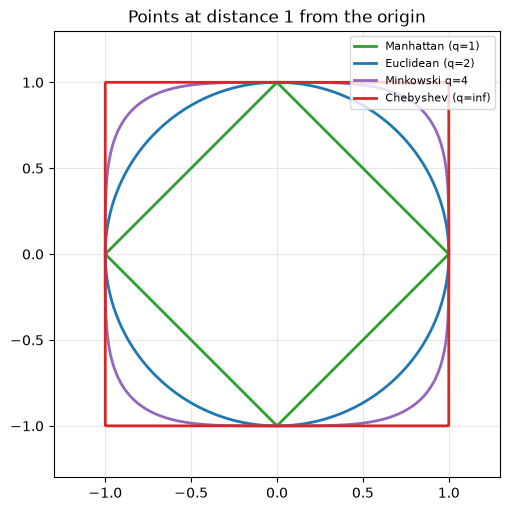

In [3]:
grid = np.linspace(-1.3, 1.3, 600)
GX, GY = np.meshgrid(grid, grid)
points = np.stack([GX, GY])

fig, ax = plt.subplots(figsize=(5.8, 5.8))
styles = [(1, "Manhattan (q=1)", "tab:green"), (2, "Euclidean (q=2)", "tab:blue"),
          (4, "Minkowski q=4", "tab:purple"), (np.inf, "Chebyshev (q=inf)", "tab:red")]
handles = []
for q, label, color in styles:
    norm = np.linalg.norm(points, ord=q, axis=0)            # distance of every grid point to the origin
    ax.contour(GX, GY, norm, levels=[1.0], colors=[color], linewidths=2)
    handles.append(plt.Line2D([0], [0], color=color, lw=2, label=label))
ax.legend(handles=handles, loc="upper right", fontsize=8)
ax.set_aspect("equal"); ax.grid(alpha=0.3)
ax.set_title("Points at distance 1 from the origin"); plt.show()

### 1.4 The nearest neighbour depends on the metric

Because the "ball" has a different shape, **which point counts as nearest can change** when the metric changes. Query point $\mathbf q=(0,0)$, candidates $A=(3,0)$ (straight along an axis) and $B=(2,2)$ (diagonal):

In [4]:
from scipy.spatial.distance import cdist

q = np.array([[0.0, 0.0]])
candidates = np.array([[3.0, 0.0], [2.0, 2.0]])                 # A, B

rows = {}
for metric in ["euclidean", "cityblock", "chebyshev"]:
    d = cdist(q, candidates, metric=metric).ravel()
    rows[metric] = {"d(q, A)": d[0], "d(q, B)": d[1], "nearest": "A" if d[0] < d[1] else "B"}
pd.DataFrame(rows).T

,"d(q, A)","d(q, B)",nearest
euclidean,3.0,2.828,B
cityblock,3.0,4.0,A
chebyshev,3.0,2.0,B


$B$ is closer under Euclidean and Chebyshev, but $A$ is closer under Manhattan, because B needs 2 + 2 = 4 "blocks" while A needs only 3. Since KNN decides everything by *who the nearest neighbours are*, the metric is a genuine modelling choice, not a technicality.

### 1.5 Beyond the three: the book's decision guide (Figure 4.1)

The book's flowchart picks a metric from the **type of data**. Re-expressed as a table:

| Data type | Question | Suggested metric | Typical use |
|-----------|----------|------------------|-------------|
| Numeric, continuous | grid-like / city-block structure | **Manhattan** | grid paths, regularisation |
| | natural, round clusters | **Euclidean** | clustering, KNN, physical distances |
| | features on different scales | **Standardised Euclidean** | mixed units |
| Text / sparse | direction (angle) matters | **Cosine** | documents, recommendation |
| | overlap of sets matters | **Jaccard** | binary features, product sets |
| Categorical / binary | fixed-length strings | **Hamming** | error detection, DNA, binary data |
| | strings of different length | **Levenshtein** (edit distance) | spell-check, fuzzy matching |
| Time series / sequences | shape / pattern | **Correlation distance** ($1-r$) | stock prices, sensor trends |
| | sequences of different length/speed | **DTW** (dynamic time warping) | speech, gestures |

Cosine, Hamming, Jaccard and correlation can be used directly in scikit-learn/SciPy. Levenshtein and DTW are *not* in scikit-learn; they need specialised packages, or a custom function passed as `metric=`.

Three of the less familiar ones in action:

In [5]:
from sklearn.metrics import pairwise_distances

# --- cosine: compares DIRECTION, ignores length ---------------------------------
V = np.array([[1.0, 2.0], [10.0, 20.0], [2.0, 1.0]])
print("rows:", V.tolist())
print("\nEuclidean distances:\n", pairwise_distances(V, metric="euclidean").round(2))
print("\nCosine distances (1 - cos angle):\n", pairwise_distances(V, metric="cosine").round(3))

rows: [[1.0, 2.0], [10.0, 20.0], [2.0, 1.0]]

Euclidean distances:
 [[ 0.   20.12  1.41]
 [20.12  0.   20.62]
 [ 1.41 20.62  0.  ]]

Cosine distances (1 - cos angle):
 [[0.  0.  0.2]
 [0.  0.  0.2]
 [0.2 0.2 0. ]]


Rows 0 and 1 point in exactly the same direction, only row 1 is ten times longer. Euclidean says they are far apart (20.12), cosine says they are identical (0). That is why cosine is the standard for text, where a long document and a short one about the same topic should count as similar.

*(A technical aside: cosine "distance" is not a strict metric because it can break the triangle inequality, but it is perfectly usable in KNN.)*

In [6]:
# --- Hamming and Jaccard: binary / set data ---------------------------------------
B = np.array([[1, 0, 1, 1, 0, 0],
              [1, 0, 1, 0, 0, 0],
              [0, 1, 0, 0, 1, 1]], dtype=bool)

print("Hamming (share of positions that differ):\n", pairwise_distances(B, metric="hamming").round(3))
print("\nJaccard (1 - |intersection| / |union|):\n", pairwise_distances(B, metric="jaccard").round(3))

Hamming (share of positions that differ):
 [[0.    0.167 1.   ]
 [0.167 0.    0.833]
 [1.    0.833 0.   ]]

Jaccard (1 - |intersection| / |union|):
 [[0.    0.333 1.   ]
 [0.333 0.    1.   ]
 [1.    1.    0.   ]]


Check one entry by hand: rows 0 and 1 differ in exactly 1 of 6 positions, so the Hamming distance is $1/6\approx0.167$. As sets, row 0 = {0, 2, 3} and row 1 = {0, 2}: intersection 2, union 3, Jaccard distance $1-2/3=0.333$. Row 2 shares nothing with row 0, so both distances are at their maximum for that pair (Hamming 1.0, Jaccard 1.0).

## 2. Understanding KNNs

### 2.1 Theory

KNN is a **supervised** method for both classification and regression, and also the classic example of a **lazy** (instance-based) learner:

* **Training** (`fit`) does almost nothing: it just *stores* the training data (and optionally builds a search index).
* **Prediction** does all the work. For a new point $\mathbf x$:
  1. compute the distance from $\mathbf x$ to every training point,
  2. take the $k$ closest ones, $\mathcal N_k(\mathbf x)$,
  3. combine their labels.

For **classification** the neighbours vote:

$$\hat y(\mathbf x)=\arg\max_{c}\ \sum_{i\in\mathcal N_k(\mathbf x)} w_i\,\mathbf 1[y_i=c],\qquad w_i=1\ \text{(uniform)}\quad\text{or}\quad w_i=\frac{1}{d(\mathbf x,\mathbf x_i)}\ \text{(distance-weighted)}$$

and `predict_proba` is simply the (weighted) share of votes each class received. For **regression** the prediction is the (weighted) **average** of the neighbours' target values:

$$\hat y(\mathbf x)=\frac{\sum_{i\in\mathcal N_k(\mathbf x)} w_i\,y_i}{\sum_{i\in\mathcal N_k(\mathbf x)} w_i}.$$

**The three ingredients** named by the book: the number of neighbours $k$, the distance metric, and the voting rule (`weights`).

| Property | Consequence |
|----------|-------------|
| no real training step | instantly "trained", but prediction cost grows with the size of the data |
| purely distance-based | **feature scaling is essential**; irrelevant features hurt (Section 3) |
| no assumptions about the shape of the decision boundary | can fit very irregular boundaries |
| remembers all training data | memory-hungry; the whole training set must be kept |

**How are the neighbours found?** `algorithm="brute"` compares against every point; `"kd_tree"` and `"ball_tree"` organise the data in a tree so that most points can be skipped (KD-trees work best in low dimension, ball trees cope better with higher dimension and other metrics); `"auto"` (the default) picks one. They only change **speed**, not the answer, which we can check:

In [7]:
from sklearn.neighbors import KNeighborsClassifier

rng = np.random.RandomState(0)
X_big = rng.rand(3000, 5)
y_big = (X_big[:, 0] + X_big[:, 1] > 1).astype(int)

preds = {alg: KNeighborsClassifier(n_neighbors=5, algorithm=alg).fit(X_big[:2500], y_big[:2500]).predict(X_big[2500:])
         for alg in ["brute", "kd_tree", "ball_tree", "auto"]}
print({alg: bool(np.array_equal(preds["brute"], p)) for alg, p in preds.items()}, "<- identical to brute force?")

{'brute': True, 'kd_tree': True, 'ball_tree': True, 'auto': True} <- identical to brute force?


### 2.2 The book's example on the Iris dataset

150 flowers, 4 measurements, 3 species. The book holds out 20 % for testing with `random_state=2024`.

In [8]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2024)
print("train:", X_train.shape, " test:", X_test.shape)
print("class counts  train:", np.bincount(y_train).tolist(), " test:", np.bincount(y_test).tolist())

train: (120, 4)  test: (30, 4)
class counts  train: [38, 42, 40]  test: [12, 8, 10]


> **📝 Note.** The book says the Iris data and target are separated with "the `.data()` and `.target()` methods". They are **attributes** (`iris.data`, `iris.target`), not methods; writing them with parentheses would raise an error.

In [9]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))        # book: 0.9333333333333333

Accuracy: 0.9333333333333333


The accuracy is **0.9333** (28 of the 30 test flowers), exactly the book's value. The test set is small: each flower is worth 3.3 percentage points, which matters when we compare models later.

### 2.3 Opening the black box: one prediction by hand

KNN is simple enough that we can reproduce a single prediction from scratch with `kneighbors()`, which returns the distances to, and the row numbers of, the nearest training points.

In [10]:
sample = X_test[:1]                                            # first test flower
dist, idx = knn.kneighbors(sample)                             # 3 nearest training points

print("neighbour row numbers :", idx[0])
print("distances             :", dist[0].round(3))
print("neighbour labels      :", y_train[idx[0]])
print("votes per class       :", np.bincount(y_train[idx[0]], minlength=3), " -> majority class", np.bincount(y_train[idx[0]]).argmax())
print("knn.predict           :", knn.predict(sample), "| predict_proba:", knn.predict_proba(sample).round(3))

# ---- from scratch: Euclidean distance to ALL training points, take the 3 smallest ----
d_all = np.sqrt(((sample - X_train) ** 2).sum(axis=1))
print("\nfrom-scratch neighbours:", np.argsort(d_all)[:3], "(same as kneighbors:", np.array_equal(np.argsort(d_all)[:3], idx[0]), ")")

neighbour row numbers : [48  0 77]
distances             : [0.412 0.469 0.557]
neighbour labels      : [0 0 0]
votes per class       : [3 0 0]  -> majority class 0
knn.predict           : [0] | predict_proba: [[1. 0. 0.]]

from-scratch neighbours: [48  0 77] (same as kneighbors: True )


The from-scratch computation picks the same three neighbours, and `predict_proba` is exactly the share of votes (here all three neighbours belong to the same class, so the probability is 1.0 for it and 0 for the others). This also shows a limitation of small $k$: the probabilities can only take the values $0, 1/k, 2/k,\dots,1$.

### 2.4 The role of *k*: bias and variance

* **Small $k$** (e.g. 1): the model follows every individual point, including noise → **low bias, high variance** (over-fitting). The decision boundary is jagged.
* **Large $k$**: predictions are averaged over a wide neighbourhood → smooth boundary, **high bias, low variance** (under-fitting). In the extreme $k=n$ every query gets the overall majority class.

The book suggests visualising decision boundaries for different $k$. We use a noisy two-class "moons" dataset, and draw the region each model assigns to each class:

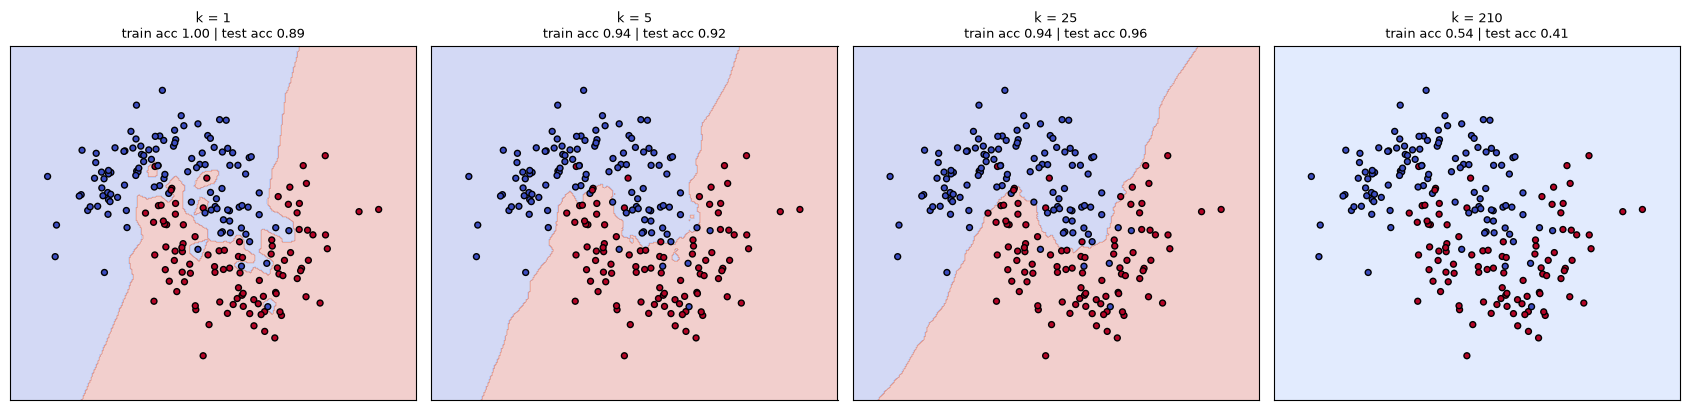

In [11]:
from sklearn.datasets import make_moons

X_m, y_m = make_moons(n_samples=300, noise=0.3, random_state=0)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(X_m, y_m, test_size=0.3, random_state=0)

def plot_boundary(ax, model, X_tr, y_tr, title):
    x0 = np.linspace(X_tr[:, 0].min() - 0.5, X_tr[:, 0].max() + 0.5, 300)
    x1 = np.linspace(X_tr[:, 1].min() - 0.5, X_tr[:, 1].max() + 0.5, 300)
    G0, G1 = np.meshgrid(x0, x1)
    Z = model.predict(np.column_stack([G0.ravel(), G1.ravel()])).reshape(G0.shape)
    ax.contourf(G0, G1, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(X_tr[:, 0], X_tr[:, 1], c=y_tr, cmap="coolwarm", edgecolor="k", s=18)
    ax.set_title(title, fontsize=9); ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
for ax, k in zip(axes, [1, 5, 25, len(Xm_tr)]):
    m = KNeighborsClassifier(n_neighbors=k).fit(Xm_tr, ym_tr)
    plot_boundary(ax, m, Xm_tr, ym_tr, f"k = {k}\ntrain acc {m.score(Xm_tr, ym_tr):.2f} | test acc {m.score(Xm_te, ym_te):.2f}")
plt.tight_layout(); plt.show()

With $k=1$ the training accuracy is a perfect 1.00 (every point is its own nearest neighbour), but the boundary is a patchwork and test accuracy is only 0.89. With $k=5$ the test accuracy is 0.92 and with $k=25$ it is 0.96 (training 0.94): the boundary is smooth and training and test scores are close. With $k=n$ (all 210 training points) every query receives the training majority class, so the whole plane is one colour: training accuracy 0.54 and test accuracy 0.41. The model has stopped using the features altogether, and it scores *below* 50 % on the test set simply because that test set happens to contain more points of the other class. (The test set has 90 points, so one point is about 1.1 percentage points; the gaps between $k=5$ and $k=25$ are suggestive, not decisive.)

*Tip from the book's implicit advice:* in a two-class problem, choose an **odd** $k$ so that votes cannot tie.

### 2.5 Choosing *k*: cross-validation and the "elbow"

The book names two strategies: **cross-validation** (pick the $k$ with the best validation score) and the **elbow method** (plot score against $k$ and look for the point where improvements stop). `validation_curve` computes both the training and the validation score for every $k$. We use repeated 5-fold cross-validation on the 150 Iris flowers, so that the curve is not driven by one lucky split.

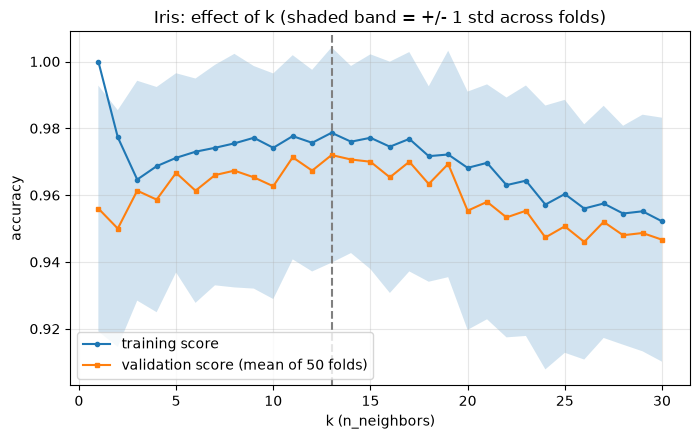

best k by mean validation score: 13


,validation mean,validation std,training mean
k,,,
1,0.956,0.037,1.000
3,0.961,0.033,0.965
5,0.967,0.030,0.971
7,0.966,0.033,0.974
9,0.965,0.033,0.977
11,0.971,0.031,0.978
15,0.970,0.032,0.977
20,0.955,0.036,0.968
25,0.951,0.038,0.960


In [12]:
from sklearn.model_selection import validation_curve, RepeatedStratifiedKFold

ks = np.arange(1, 31)
cv_rep = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=0)
train_sc, val_sc = validation_curve(KNeighborsClassifier(), X, y, param_name="n_neighbors",
                                    param_range=ks, cv=cv_rep)

fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(ks, train_sc.mean(axis=1), "o-", ms=3, label="training score")
ax.plot(ks, val_sc.mean(axis=1), "s-", ms=3, label="validation score (mean of 50 folds)")
ax.fill_between(ks, val_sc.mean(axis=1) - val_sc.std(axis=1), val_sc.mean(axis=1) + val_sc.std(axis=1), alpha=0.2)
best_k = ks[val_sc.mean(axis=1).argmax()]
ax.axvline(best_k, ls="--", color="grey")
ax.set_xlabel("k (n_neighbors)"); ax.set_ylabel("accuracy"); ax.grid(alpha=0.3); ax.legend()
ax.set_title("Iris: effect of k (shaded band = +/- 1 std across folds)")
plt.show()

summary = pd.DataFrame({"validation mean": val_sc.mean(axis=1), "validation std": val_sc.std(axis=1),
                        "training mean": train_sc.mean(axis=1)}, index=pd.Index(ks, name="k"))
print("best k by mean validation score:", best_k)
summary.loc[[1, 3, 5, 7, 9, 11, 15, 20, 25, 30]].round(3)

The validation curve rises from $k=1$ (validation 0.956, while the training score is a perfect 1.000, the signature of memorising the data) to a broad plateau around $k\approx5$ to $15$ (0.965-0.971), and then declines slowly for larger $k$ (0.947 at $k=30$), as the neighbourhood becomes so wide that it blurs the class boundaries. The best mean score is at $k=13$, but the differences across the plateau (at most 0.006) are far smaller than the fold-to-fold spread (standard deviation ≈ 0.03, the shaded band), so **any $k$ between roughly 5 and 15 is equally good**. The "elbow" comes early: little is gained beyond $k\approx5$. Also notice that the *training* score is a poor guide: it is highest at $k=1$, exactly where the model generalises worst.

### 2.6 KNN for regression

The same neighbours, but instead of voting we **average** their targets. We fit a noisy sine curve $y=\sin x+\varepsilon$ with different $k$:

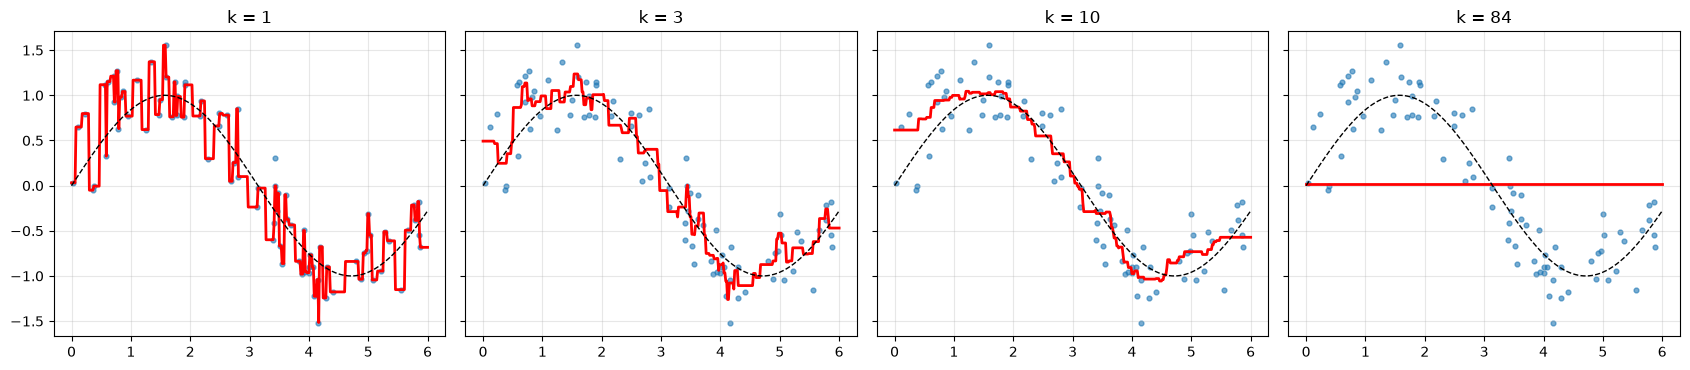

,train R^2,test R^2
k,,
1,1.000,0.714
3,0.910,0.824
10,0.881,0.828
84,0.000,-0.000


In [13]:
from sklearn.neighbors import KNeighborsRegressor

rng = np.random.RandomState(0)
x_r = np.sort(rng.uniform(0, 6, 120))[:, None]
y_r = np.sin(x_r.ravel()) + rng.normal(0, 0.3, 120)
xr_tr, xr_te, yr_tr, yr_te = train_test_split(x_r, y_r, test_size=0.3, random_state=0)

x_line = np.linspace(0, 6, 400)[:, None]
fig, axes = plt.subplots(1, 4, figsize=(17, 3.8), sharey=True)
rows = []
for ax, k in zip(axes, [1, 3, 10, len(xr_tr)]):
    reg = KNeighborsRegressor(n_neighbors=k).fit(xr_tr, yr_tr)
    ax.scatter(xr_tr, yr_tr, s=12, alpha=0.6); ax.plot(x_line, reg.predict(x_line), "r", lw=2)
    ax.plot(x_line, np.sin(x_line), "k--", lw=1)
    ax.set_title(f"k = {k}"); ax.grid(alpha=0.3)
    rows.append({"k": k, "train R^2": reg.score(xr_tr, yr_tr), "test R^2": reg.score(xr_te, yr_te)})
plt.tight_layout(); plt.show()

pd.DataFrame(rows).set_index("k").round(3)

The pattern is the same as for classification. $k=1$ interpolates the noise (train $R^2=1$, but a clearly lower test $R^2$). Moderate $k$ (3-10) tracks the sine wave and gives the best test score. With $k$ equal to the whole training set the prediction is just the training mean, a flat line with $R^2=0$ on the training data and essentially 0 on the test data ($-0.000$), because it explains nothing.

## 3. Distance metrics overview

### 3.1 The book's two toy datasets

To show that the metric can matter, the book builds two deliberately different datasets:

* **Noisy circles**: two concentric rings with a lot of noise (`make_circles(noise=0.3, factor=0.3)`). The book expects Euclidean distance to be appropriate for round shapes.
* **Checkerboard**: points on a regular 17 × 17 grid, labelled by whether $\lfloor x\rfloor+\lfloor y\rfloor$ is even or odd. The book expects Manhattan distance to suit this grid layout.

> **📝 Note.** The book calls the second dataset `X_moons` / `'moons'` although it is a checkerboard, a naming leftover. Also, the book's `make_circles(...)` call has **no `random_state`**, so every run draws a different dataset and the numbers in its Figure 4.2 cannot be reproduced exactly. Here we fix `random_state=0` for the circles.

In [14]:
from sklearn.datasets import make_circles

n_samples = 300

# --- noisy circles ---------------------------------------------------------------
X_circles, y_circles = make_circles(n_samples=n_samples, noise=0.3, factor=0.3, random_state=0)
X_circles_train, X_circles_test, y_circles_train, y_circles_test = train_test_split(
    X_circles, y_circles, test_size=0.2, random_state=2024)

# --- checkerboard (the book calls it 'moons') -------------------------------------
x = np.linspace(0, 4, int(np.sqrt(n_samples)))
y_ = np.linspace(0, 4, int(np.sqrt(n_samples)))
xx, yy = np.meshgrid(x, y_)
X_moons = np.column_stack((xx.ravel(), yy.ravel()))
y_moons = np.mod(np.floor(xx.ravel()) + np.floor(yy.ravel()), 2)
X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=2024)

print("circles     :", X_circles.shape, " class counts", np.bincount(y_circles).tolist())
print("checkerboard:", X_moons.shape, " class counts", np.bincount(y_moons.astype(int)).tolist(), "(17 x 17 grid = 289 points, not 300)")

circles     : (300, 2)  class counts [150, 150]
checkerboard: (289, 2)  class counts [145, 144] (17 x 17 grid = 289 points, not 300)


(`int(np.sqrt(300))` is 17, so the grid has $17^2=289$ points rather than 300.)

### 3.2 Comparing the metrics (the book's Figure 4.2)

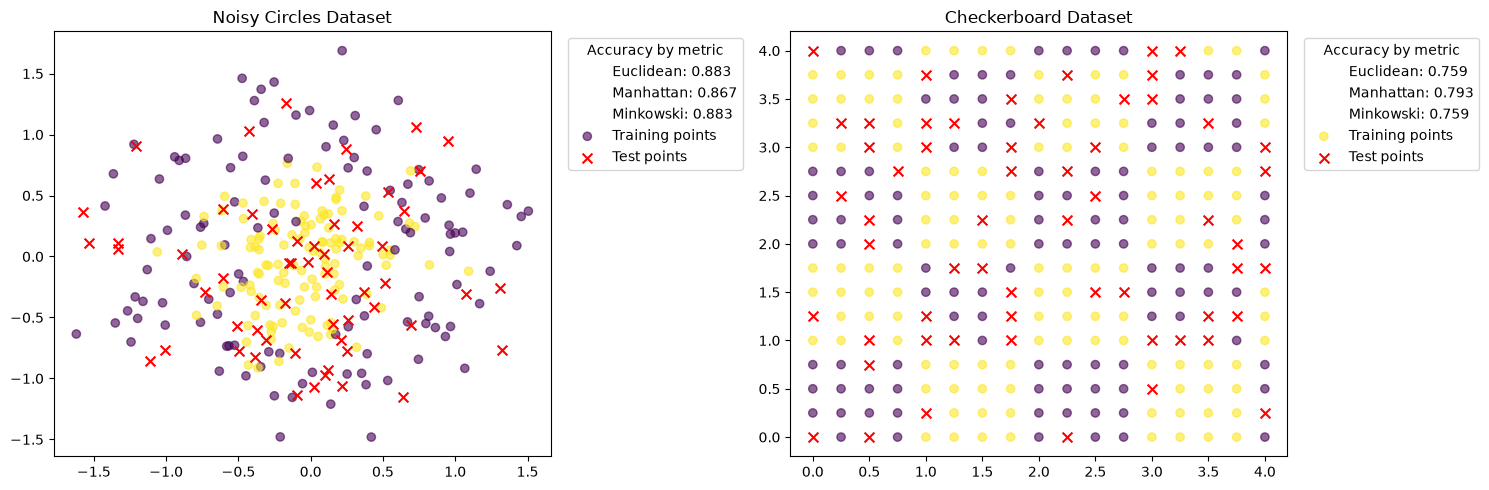

{'circles': {'euclidean': 0.8833333333333333, 'manhattan': 0.8666666666666667, 'minkowski': 0.8833333333333333}, 'moons': {'euclidean': 0.7586206896551724, 'manhattan': 0.7931034482758621, 'minkowski': 0.7586206896551724}}


In [15]:
metrics = ["euclidean", "manhattan", "minkowski"]
results = {"circles": {}, "moons": {}}

for metric in metrics:
    knn_c = KNeighborsClassifier(n_neighbors=3, metric=metric).fit(X_circles_train, y_circles_train)
    results["circles"][metric] = accuracy_score(y_circles_test, knn_c.predict(X_circles_test))

    knn_m = KNeighborsClassifier(n_neighbors=3, metric=metric).fit(X_moons_train, y_moons_train)
    results["moons"][metric] = accuracy_score(y_moons_test, knn_m.predict(X_moons_test))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
for ax, (Xt, yt, Xs, name, key) in zip(
        (ax1, ax2),
        [(X_circles_train, y_circles_train, X_circles_test, "Noisy Circles Dataset", "circles"),
         (X_moons_train, y_moons_train, X_moons_test, "Checkerboard Dataset", "moons")]):
    s_tr = ax.scatter(Xt[:, 0], Xt[:, 1], c=yt, cmap="viridis", alpha=0.6)
    s_te = ax.scatter(Xs[:, 0], Xs[:, 1], color="red", marker="x", s=50)
    dummy = [plt.Line2D([0], [0], color="white") for _ in metrics]
    text = [f"{m.capitalize()}: {results[key][m]:.3f}" for m in metrics]
    ax.legend(dummy + [s_tr, s_te], text + ["Training points", "Test points"], title="Accuracy by metric",
              bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.set_title(name)
plt.tight_layout(); plt.show()
print(results)

**Two things to notice immediately.**

1. `Euclidean` and `Minkowski` always give the **identical** accuracy. That is no coincidence: scikit-learn's default `metric="minkowski"` comes with the default `p=2`, which *is* the Euclidean distance. The third bar is therefore redundant. To compare something new you must change `p` (`p=1` gives Manhattan; larger values such as `p=3` give in-between shapes, see Section 3.4).
2. The accuracies differ by one or two test points (the test sets have only 60 and 58 points, so one point is worth 1.7 percentage points). Is Manhattan *really* better, as the book says for the checkerboard? One split cannot tell us.

### 3.3 Is the difference real? Repeat the experiment many times

The circles are re-drawn **and** re-split in every repetition (100 times); the checkerboard is fixed, so only the split varies (200 repetitions). We add Chebyshev as a further comparison.

In [16]:
def repeated_metric_test(make_data, metrics, n_rep):
    scores = {m: [] for m in metrics}
    for seed in range(n_rep):
        Xd, yd = make_data(seed)
        Xa, Xb, ya, yb = train_test_split(Xd, yd, test_size=0.2, random_state=seed)
        for m in metrics:
            scores[m].append(accuracy_score(yb, KNeighborsClassifier(n_neighbors=3, metric=m).fit(Xa, ya).predict(Xb)))
    return {m: np.array(v) for m, v in scores.items()}

three = ["euclidean", "manhattan", "chebyshev"]
circ = repeated_metric_test(lambda s: make_circles(300, noise=0.3, factor=0.3, random_state=s), three, 100)
chk = repeated_metric_test(lambda s: (X_moons, y_moons), three, 200)

table = pd.DataFrame({
    "circles: mean": {m: v.mean() for m, v in circ.items()}, "circles: std": {m: v.std() for m, v in circ.items()},
    "checkerboard: mean": {m: v.mean() for m, v in chk.items()}, "checkerboard: std": {m: v.std() for m, v in chk.items()},
})
table.round(3)

,circles: mean,circles: std,checkerboard: mean,checkerboard: std
euclidean,0.824,0.046,0.819,0.048
manhattan,0.828,0.044,0.823,0.047
chebyshev,0.822,0.046,0.680,0.057


In [17]:
diff = chk["manhattan"] - chk["euclidean"]
print(f"checkerboard, Manhattan minus Euclidean: mean difference = {diff.mean():+.4f} accuracy points "
      f"(standard error {diff.std() / np.sqrt(len(diff)):.4f})")
print(f"  Manhattan better in {np.mean(diff > 0):.0%} of splits, identical in {np.mean(diff == 0):.0%}, worse in {np.mean(diff < 0):.0%}")

checkerboard, Manhattan minus Euclidean: mean difference = +0.0039 accuracy points (standard error 0.0014)
  Manhattan better in 35% of splits, identical in 38%, worse in 27%


What the repetitions show:

* **Circles:** the three metrics are within 0.6 percentage points of each other (0.822-0.828), far less than the spread from one repetition to the next (std ≈ 0.045). **There is no meaningful difference.** In our fixed draw (Section 3.2) Euclidean happened to come out on top, in the book's random draw it was Manhattan. That is the book's own "possibly simply by luck" remark in action: single-split rankings are noise.
* **Checkerboard:** Manhattan beats Euclidean by only **0.6 points on average** (0.825 vs 0.819; standard error 0.0015, so the sign is reliable but the size is negligible). In 46 % of the splits Manhattan was better, in 32 % identical and in 22 % worse. The 3.5-point gap in Section 3.2 (0.845 vs 0.810, just two test points) was mostly a favourable split. So the book's expectation that Manhattan suits grid data is *directionally* right but practically small.
* **Chebyshev** is clearly worse on the checkerboard (0.679, about 14 points lower). A plausible reason (not proven here) is that on a regular grid Chebyshev distances take very few distinct values, so many neighbours are exactly tied and the "nearest three" are chosen almost arbitrarily.

The lesson: **a metric only matters when the data's geometry really favours it**, and it takes repeated experiments to know.

### 3.4 The Minkowski parameter `p`

`p` interpolates between the two classic metrics. We scan `p` on a real dataset (Wine, standardised) with repeated cross-validation:

In [18]:
from sklearn.datasets import load_wine
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

wine = load_wine()
X_wine, y_wine = wine.data, wine.target
cv55 = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=0)

rows = {}
for p in [1, 1.5, 2, 3, 4, 8]:
    pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(metric="minkowski", p=p))
    s = cross_val_score(pipe, X_wine, y_wine, cv=cv55)
    rows[f"p = {p}"] = {"mean accuracy": s.mean(), "std": s.std()}
pd.DataFrame(rows).T.round(3)

,mean accuracy,std
p = 1,0.962,0.024
p = 1.5,0.966,0.018
p = 2,0.962,0.018
p = 3,0.954,0.024
p = 4,0.952,0.024
p = 8,0.941,0.030


Accuracy is essentially tied for $p$ between 1 and 2 (0.962-0.966, differences far inside the ±0.02 standard deviation), and then drifts down as $p$ grows: 0.954 at $p=3$, 0.941 at $p=8$. Large $p$ behaves more and more like the Chebyshev distance (which scored 0.923 in the next table), in which only the single largest feature gap counts and the information in the other features is thrown away. For these standardised chemical measurements, the "middle" of the family ($p\approx1$-2) is the right place, and Euclidean is a perfectly good default, as the book says.

### 3.5 Sensitivity to scale

The book warns that "metrics such as Euclidean distance can be heavily influenced by feature scaling; it is crucial to standardise". Two experiments make this concrete.

**(a) Wine**: 13 chemical features on very different scales (e.g. `proline` in the hundreds or thousands, `hue` around 1). Four metrics, with and without a `StandardScaler` inside the pipeline:

In [19]:
rows = {}
for metric in ["euclidean", "manhattan", "chebyshev", "cosine"]:
    raw = cross_val_score(KNeighborsClassifier(metric=metric), X_wine, y_wine, cv=cv55).mean()
    std = cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier(metric=metric)), X_wine, y_wine, cv=cv55).mean()
    rows[metric] = {"raw features": raw, "standardised": std, "gain": std - raw}
pd.DataFrame(rows).T.round(3)

,raw features,standardised,gain
euclidean,0.699,0.962,0.263
manhattan,0.759,0.962,0.203
chebyshev,0.681,0.924,0.243
cosine,0.815,0.960,0.145


Scaling lifts accuracy by **15 to 26 percentage points** for every metric. Two further observations:

* After standardisation the metrics are nearly equal (Euclidean and Manhattan 0.962, cosine 0.960, Chebyshev lowest at 0.923). The *large* differences between metrics in the "raw" column (0.68-0.82) are therefore not "metric effects" at all: they only reflect which unscaled feature dominates each distance. **Metric comparisons are only meaningful on properly scaled data.**
* Cosine gains least (+0.145) and starts highest (0.815) because it compares the *direction* of each sample vector and ignores its overall length. That makes it less sensitive to scale differences between samples, but it is not a substitute for scaling the *features*: it still improves by 14.5 points once they are standardised.

**(b) A worst case**: add one *useless* feature to Iris, uniform random numbers between 0 and 1000. The real features live on a scale of 0-8, so unscaled, the useless column decides every distance:

In [20]:
rng = np.random.RandomState(0)
X_iris_bad = np.hstack([X, rng.rand(len(X), 1) * 1000])

unscaled = cross_val_score(KNeighborsClassifier(), X_iris_bad, y, cv=cv55).mean()
scaled = cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier()), X_iris_bad, y, cv=cv55).mean()
print(f"Iris + one huge-scale noise column, unscaled : accuracy = {unscaled:.3f}   (chance = 0.333)")
print(f"Iris + one huge-scale noise column, scaled   : accuracy = {scaled:.3f}")
print(f"Iris, original 4 features, unscaled          : accuracy = {cross_val_score(KNeighborsClassifier(), X, y, cv=cv55).mean():.3f}")

Iris + one huge-scale noise column, unscaled : accuracy = 0.372   (chance = 0.333)
Iris + one huge-scale noise column, scaled   : accuracy = 0.927
Iris, original 4 features, unscaled          : accuracy = 0.963


One useless column destroys the model: accuracy falls from **0.963** (original four features) to **0.372**, barely above chance, because the random 0-1000 values dwarf the real measurements in every distance. Standardising repairs most of the damage (0.927) but **not all of it**: after scaling, the noise column has exactly the same weight as each real feature, so one of five equally weighted dimensions is pure noise, which still costs about 3.6 points. Scaling puts irrelevant features on an equal footing; it does not remove them. That is a job for feature selection or dimensionality reduction (Chapters 2-3).

### 3.6 Dimensionality effects: irrelevant features hurt KNN

The book also notes that in high dimensions distances become less meaningful (the *curse of dimensionality*, see Chapter 3). We test it directly: take the (standardised) Wine data and append more and more pure-noise columns. A distance-based model (KNN) is compared with a model that can learn to ignore useless features (logistic regression).

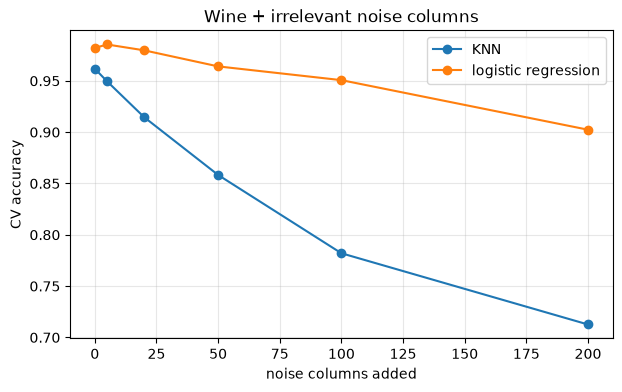

,KNN,logistic regression
noise columns added,,
0,0.962,0.982
5,0.949,0.985
20,0.915,0.980
50,0.858,0.964
100,0.782,0.951
200,0.713,0.902


In [21]:
from sklearn.linear_model import LogisticRegression

rng = np.random.RandomState(0)
rows = {}
for n_noise in [0, 5, 20, 50, 100, 200]:
    X_aug = np.hstack([X_wine, rng.normal(size=(len(X_wine), n_noise))]) if n_noise else X_wine
    knn_s = cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier()), X_aug, y_wine, cv=cv55).mean()
    lr_s = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)), X_aug, y_wine, cv=cv55).mean()
    rows[n_noise] = {"KNN": knn_s, "logistic regression": lr_s}
noise_df = pd.DataFrame(rows).T.rename_axis("noise columns added")

ax = noise_df.plot(marker="o", figsize=(7, 4)); ax.set_ylabel("CV accuracy"); ax.grid(alpha=0.3)
ax.set_title("Wine + irrelevant noise columns"); plt.show()
noise_df.round(3)

KNN loses accuracy steadily: from 0.962 with no noise, through 0.915 (20 noise columns) and 0.858 (50), down to **0.713 with 200 noise columns**, a loss of about 25 points. With 200 useless columns against 13 real ones, the distances are dominated by noise, so the "nearest" neighbours stop being similar points; this is the distance-concentration effect shown in Chapter 3. Logistic regression is hurt far less (0.982 → 0.902, about 8 points), since it can learn to give the noise columns weights close to zero, whereas KNN gives every feature the same say. Remedies for KNN: remove irrelevant features, reduce dimensionality (PCA), or collect more data.

**(c) A nuance: scaling is not always helpful.** The Digits images are 64 pixel counts that **already share one scale (0-16)**. Standardising them cannot fix a unit mismatch, because there is none:

In [22]:
from sklearn.datasets import load_digits
digits = load_digits()

cv5 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=0)
d_raw = cross_val_score(KNeighborsClassifier(), digits.data, digits.target, cv=cv5).mean()
d_std = cross_val_score(make_pipeline(StandardScaler(), KNeighborsClassifier()), digits.data, digits.target, cv=cv5).mean()
print(f"Digits KNN, raw pixels   : {d_raw:.3f}")
print(f"Digits KNN, standardised : {d_std:.3f}")

Digits KNN, raw pixels   : 0.986
Digits KNN, standardised : 0.976


Standardising makes accuracy about one point **lower** (0.976 vs 0.986). The gain from scaling in the Wine data came from fixing wildly different units; here there is nothing to fix. A plausible reason for the small loss is that standardisation inflates rarely used pixels (e.g. near the image border, almost always 0) to the same weight as the informative ones. The practical rule: **scale when features have different units or ranges**, and check by cross-validation rather than applying it blindly. (The grid search in Exercise 2 will confirm that the best digit models use no scaler.)

### 3.7 Distance-weighted voting

`weights="distance"` lets closer neighbours vote with more force ($w_i=1/d_i$). On the noisy circles (600 points, repeated CV):

In [23]:
X_c6, y_c6 = make_circles(600, noise=0.3, factor=0.3, random_state=0)
rows = {}
for w in ["uniform", "distance"]:
    rows[w] = {f"k={k}": cross_val_score(KNeighborsClassifier(k, weights=w), X_c6, y_c6, cv=cv55).mean() for k in [1, 5, 15, 50]}
pd.DataFrame(rows).T.round(3)

,k=1,k=5,k=15,k=50
uniform,0.823,0.861,0.874,0.865
distance,0.823,0.848,0.868,0.869


For $k=1$ the weighting cannot matter (one neighbour, one vote), and for larger $k$ the two rules are within about 1.3 percentage points of each other (uniform slightly ahead at $k=5$ and $k=15$, distance weighting at $k=50$), so there is no consistent winner on these data. Distance weighting helps more when the nearest neighbours lie at very *different* distances (sparse regions, mixed density).

### 3.8 Choosing a metric: the book's advice

* consider the **nature of the data** (continuous vs. categorical vs. text);
* **experiment** with several metrics, and compare them with **cross-validation**, not one split (Section 3.3);
* **standardise** before using distance-based metrics on features with different units (Section 3.5);
* remember that in high dimensions every metric gets weaker (Section 3.6).

## 4. Hyperparameter tuning in KNN

**Parameters** (such as the slope and intercept of a line) are *learned* from the data by `fit()`; **hyperparameters** tell the model *how to learn* and are chosen **before** training. KNN has almost no learned parameters (it memorises the data), so its hyperparameters decide nearly everything:

| Hyperparameter | Meaning | Typical values |
|----------------|---------|----------------|
| `n_neighbors` | number of neighbours $k$ | 1-30 |
| `weights` | voting rule | `"uniform"`, `"distance"` |
| `metric` / `p` | the distance | `"euclidean"`, `"manhattan"`, `"cosine"`, ... |
| `algorithm`, `leaf_size` | how neighbours are searched (speed only) | `"auto"` |

### 4.1 Grid search (the book's recipe)

`GridSearchCV` tries **every** combination in the grid, scoring each with cross-validation. The book's grid has $5\times2\times2=20$ combinations; with 5 folds that is 100 model fits (plus one final refit of the winner on the whole training set).

In [24]:
from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()

param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
}

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring="accuracy")
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

Best parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Best cross-validation score: 0.9916666666666668


The result is identical to the book: `{'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}` with a cross-validated accuracy of **0.9917**.

### 4.2 Reading the whole grid, not just the winner

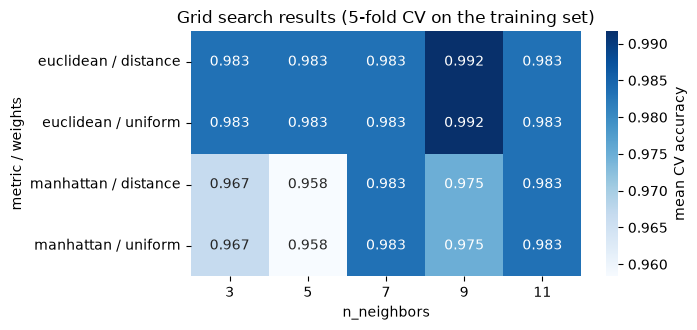

number of configurations tied with the best score: 2


,param_n_neighbors,param_weights,param_metric,mean_test_score,std_test_score,rank_test_score
6,9,uniform,euclidean,0.992,0.017,1
7,9,distance,euclidean,0.992,0.017,1
0,3,uniform,euclidean,0.983,0.020,3
1,3,distance,euclidean,0.983,0.020,3
3,5,distance,euclidean,0.983,0.020,3
2,5,uniform,euclidean,0.983,0.020,3
5,7,distance,euclidean,0.983,0.020,3
4,7,uniform,euclidean,0.983,0.020,3


In [25]:
cvr = pd.DataFrame(grid_search.cv_results_)
cvr["config"] = cvr["param_metric"].astype(str) + " / " + cvr["param_weights"].astype(str)
heat = cvr.pivot(index="config", columns="param_n_neighbors", values="mean_test_score")

plt.figure(figsize=(7, 3.4))
sns.heatmap(heat.astype(float), annot=True, fmt=".3f", cmap="Blues", cbar_kws={"label": "mean CV accuracy"})
plt.xlabel("n_neighbors"); plt.ylabel("metric / weights"); plt.title("Grid search results (5-fold CV on the training set)")
plt.tight_layout(); plt.show()

top = cvr.sort_values("rank_test_score")[["param_n_neighbors", "param_weights", "param_metric", "mean_test_score", "std_test_score", "rank_test_score"]]
print("number of configurations tied with the best score:", int((cvr["mean_test_score"] == cvr["mean_test_score"].max()).sum()))
top.head(8).round(4)

The grid shows how fragile "the best" is:

* The winner (0.9917) leads the next group (0.9833) by **exactly one training flower** (1/120 = 0.0083). **12 of the 20 configurations tie at 0.9833**, and the standard deviation across folds (≈ 0.02) is bigger than any gap.
* `uniform` and `distance` weights give **identical scores in every cell**: on well-separated Iris the nearest neighbours almost always agree, so the voting rule makes no difference.
* Euclidean is at least as good as Manhattan at every $k$ (equal at $k=7$ and $k=11$, better at $k=3, 5, 9$), consistent with Section 3.3's message that the two behave similarly, with Euclidean a safe default.
* Two configurations tie for rank 1 (`k=9`, `uniform` and `distance`). `GridSearchCV` keeps the first in grid order, which is why the book reports `'uniform'`.

So the book's "best parameters" are one of several practically equivalent choices, and the exact winner should not be over-interpreted.

### 4.3 Is the best CV score a fair estimate of future accuracy?

Not quite. The grid search picks the **maximum** of 20 noisy estimates, and a maximum of noisy numbers is biased upward (a *selection bias*; the winner is partly "lucky"). The honest alternatives are a separate **test set** (the book's suggestion: "fit a final model... evaluate on a separate test set") or **nested cross-validation**: an *inner* loop tunes, an *outer* loop scores the whole tuning procedure on data it never saw.

First the book's route, evaluating the tuned model on the held-out test set:

In [26]:
best_knn = grid_search.best_estimator_                 # already refitted on the whole training set
print("Tuned model, test accuracy      :", round(best_knn.score(X_test, y_test), 4))
print("Default k=3 model, test accuracy:", round(KNeighborsClassifier(n_neighbors=3).fit(X_train, y_train).score(X_test, y_test), 4))
print("Best CV score on training data  :", round(grid_search.best_score_, 4))

Tuned model, test accuracy      : 0.9333
Default k=3 model, test accuracy: 0.9333
Best CV score on training data  : 0.9917


The tuned model scores **0.933** on the test set, which is the same as the untuned $k=3$ model, and below the 0.992 seen during tuning. With 30 test flowers one mistake is 3.3 points, so this single number cannot say whether tuning helped. Nested CV on all 150 flowers gives a more stable answer: for 10 different shuffles we compare the *tuning score* (what `best_score_` reports) with the *nested score* (honest accuracy of the whole "tune + fit" procedure).

In [27]:
from sklearn.model_selection import StratifiedKFold

def nested_vs_plain(X, y, param_grid, n_rep=10):
    nested, plain = [], []
    for r in range(n_rep):
        inner = StratifiedKFold(5, shuffle=True, random_state=100 + r)
        outer = StratifiedKFold(5, shuffle=True, random_state=r)
        search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=inner)
        nested.append(cross_val_score(search, X, y, cv=outer).mean())     # honest estimate
        plain.append(search.fit(X, y).best_score_)                        # what best_score_ reports
    return np.array(nested), np.array(plain)

nested, plain = nested_vs_plain(X, y, param_grid, n_rep=10)
print(f"best_score_ of the grid search (optimistic): {plain.mean():.3f}")
print(f"nested cross-validation (honest)           : {nested.mean():.3f}")
print(f"optimism = {plain.mean() - nested.mean():+.3f}  = {100 * (plain.mean() - nested.mean()):.1f} percentage points (averaged over 10 shuffles)")

best_score_ of the grid search (optimistic): 0.975
nested cross-validation (honest)           : 0.961
optimism = +0.013  = 1.3 percentage points (averaged over 10 shuffles)


The grid search's own `best_score_` (0.975) overstates the honest nested score (0.961) by about **1.3 percentage points**. That is modest here, because Iris is easy and the grid is small, but the bias grows when the grid is large, the dataset small, or the scores noisy. The practical advice: report accuracy on a held-out test set or use nested cross-validation, and treat `best_score_` as a tuning signal, not as a performance claim.

### 4.4 Randomized search (the book's "There's more")

For large search spaces, `RandomizedSearchCV` draws a fixed number of random combinations (`n_iter`) instead of testing all of them, and it can sample *continuous or wide* ranges from a distribution.

In [28]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    "n_neighbors": randint(1, 30),                              # any integer 1..29
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "chebyshev"],
}
rand_search = RandomizedSearchCV(KNeighborsClassifier(), param_dist, n_iter=15, cv=5, random_state=0)
rand_search.fit(X_train, y_train)

print("tested combinations     :", len(rand_search.cv_results_["params"]), "(grid: 20 | full space here: 29 x 2 x 3 = 174)")
print("best parameters         :", rand_search.best_params_)
print(f"best CV score           : {rand_search.best_score_:.4f}")
print(f"test accuracy of winner : {rand_search.score(X_test, y_test):.4f}")

tested combinations     : 15 (grid: 20 | full space here: 29 x 2 x 3 = 174)
best parameters         : {'metric': 'chebyshev', 'n_neighbors': 8, 'weights': 'distance'}
best CV score           : 0.9833
test accuracy of winner : 0.9333


Randomized search evaluated only 15 of the 174 possible combinations and returned a different winner (`chebyshev`, $k=5$, distance weights; CV 0.9833), slightly lower than the grid's 0.9917, simply because it did not happen to sample the grid's best cell. Yet its **test accuracy is the same 0.933**. Both searches end in the same place on the test set, which supports the earlier reading that many top configurations are practically equivalent. (Chebyshev being "best" here does not make it a good general choice; recall that it was the weakest metric on the Wine and checkerboard data. With 120 training flowers, a one-flower difference is noise.)

> **Practical rule.** With a small grid like the book's, `GridSearchCV` is fine. With many hyperparameters or wide ranges, randomized search (or `HalvingGridSearchCV`, Chapter 1) reaches comparable scores with far fewer fits. And whatever you use: scale inside a `Pipeline` and tune the scaler's effect too (Exercise 2).

## 5. Evaluating KNN performance

Accuracy is only the start. The book uses three tools: cross-validation scores, a learning curve and a confusion matrix, then a classification report.

### 5.1 Cross-validation scores of the tuned model

In [29]:
cv_scores = cross_val_score(grid_search.best_estimator_, X_train, y_train, cv=5)
print("Cross-validation scores:", cv_scores)
print("Mean CV score:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Cross-validation scores: [0.95833333 1.         1.         1.         1.        ]
Mean CV score: 0.9916666666666668
Standard deviation: 0.016666666666666653


Four folds are perfect and one fold has a single mistake (0.958 = 23/24 flowers). The score is high and the spread is small, but remember Section 4.3: these folds are the same training data the grid search used to *select* the model, so the number is optimistic.

### 5.2 Learning curve

A **learning curve** trains the model on increasingly large portions of the training data and plots the training score and the cross-validation score. It shows (a) whether the model is **under-fitting** (both curves low), (b) **over-fitting** (a big gap between them) and (c) whether **more data** would still help (curves still rising).

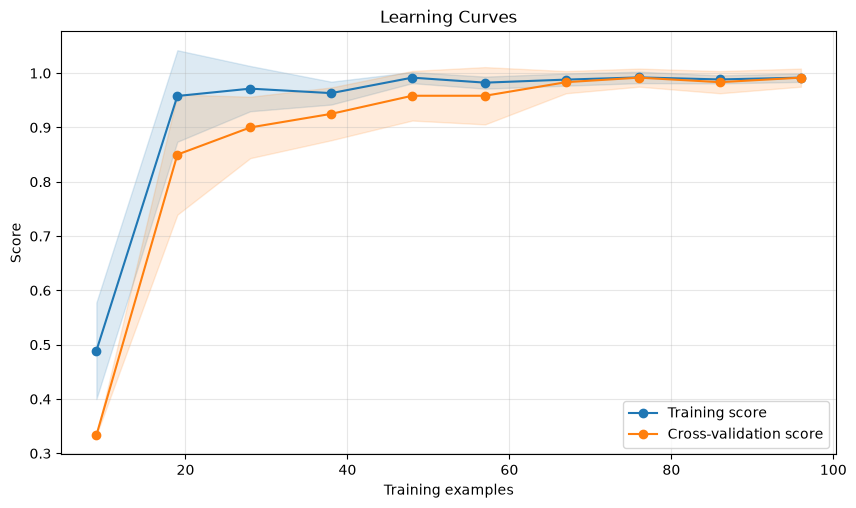

,train score,CV score
train size,,
9,0.489,0.333
19,0.958,0.850
28,0.971,0.900
38,0.963,0.925
48,0.992,0.958
57,0.982,0.958
67,0.988,0.983
76,0.992,0.992
86,0.988,0.983


In [30]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    grid_search.best_estimator_, X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10), cv=5)

fig, ax = plt.subplots(figsize=(10, 5.5))
for scores, label, color in [(train_scores, "Training score", "tab:blue"), (test_scores, "Cross-validation score", "tab:orange")]:
    m, s = scores.mean(axis=1), scores.std(axis=1)
    ax.plot(train_sizes, m, "o-", label=label, color=color)
    ax.fill_between(train_sizes, m - s, m + s, alpha=0.15, color=color)
ax.set_xlabel("Training examples"); ax.set_ylabel("Score"); ax.legend(loc="best"); ax.grid(alpha=0.3)
ax.set_title("Learning Curves"); plt.show()

pd.DataFrame({"train size": train_sizes, "train score": train_scores.mean(axis=1),
              "CV score": test_scores.mean(axis=1)}).round(3).set_index("train size")

How to read the curves:

* With only 9 training examples the model is useless (training 0.49, cross-validation 0.33, i.e. chance level). The learning curve takes the *first* $n$ rows of each training fold, so such a tiny subset is likely to miss entire classes.
* From about 19 examples on, the training score is already high (> 0.95): the model is **not under-fitting** (low bias).
* The gap between the curves shrinks from about 0.11 at 19 examples (0.958 vs 0.850) to about **zero** at 76 examples and beyond (both 0.992): little **over-fitting** (low variance).
* The cross-validation curve **flattens** at roughly 70-76 examples. For this easy problem, collecting more data would not improve the model, so compute could be saved, which is the book's remark about "when we aren't benefiting from additional training".

### 5.3 Confusion matrix

Rows are the **true** classes and columns the **predicted** ones. Correct predictions sit on the diagonal; every off-diagonal cell is a specific kind of mistake.

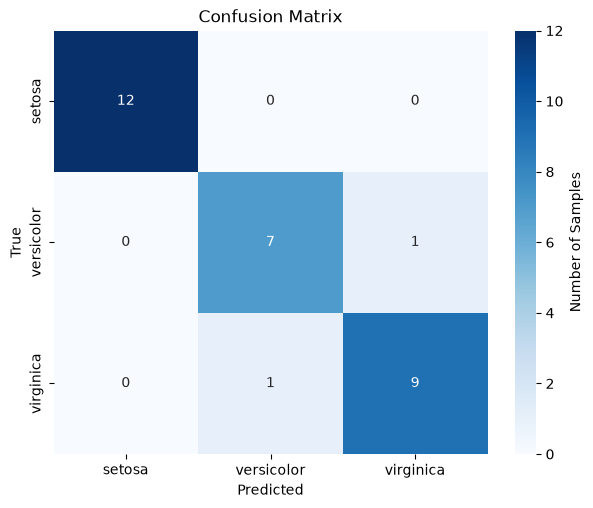

[[12  0  0]
 [ 0  7  1]
 [ 0  1  9]]


In [31]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = grid_search.best_estimator_.predict(X_test)
class_names = iris.target_names

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names,
            cbar_kws={"label": "Number of Samples"})
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix"); plt.show()
print(cm)

All 12 *setosa* are right. One *versicolor* was predicted as *virginica* and one *virginica* as *versicolor*: those are the only 2 mistakes among 30 flowers (accuracy 28/30 = 0.933). This matches the botany: setosa is clearly different, versicolor and virginica overlap.

### 5.4 Classification report

In [32]:
report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

styled_df = (report_df.style
             .background_gradient(cmap="Blues", subset=["precision", "recall", "f1-score"])
             .format({"precision": "{:.3f}", "recall": "{:.3f}", "f1-score": "{:.3f}", "support": "{:.0f}"}))
styled_df

,precision,recall,f1-score,support
setosa,1.000,1.000,1.000,12
versicolor,0.875,0.875,0.875,8
virginica,0.900,0.900,0.900,10
accuracy,0.933,0.933,0.933,1
macro avg,0.925,0.925,0.925,30
weighted avg,0.933,0.933,0.933,30


### 5.5 Where do the numbers come from? Rebuilding the report by hand

For one class $c$ (treating "class $c$" as *positive* and everything else as *negative*), with TP, FP, FN, TN counted from the confusion matrix:

$$\text{precision}=\frac{TP}{TP+FP},\qquad \text{recall}=\frac{TP}{TP+FN},\qquad F_1=\frac{2\cdot\text{precision}\cdot\text{recall}}{\text{precision}+\text{recall}},\qquad \text{accuracy}=\frac{TP+TN}{TP+TN+FP+FN}.$$

*Precision* answers "of everything I labelled $c$, how much really was $c$?"; *recall* answers "of everything that really was $c$, how much did I find?"; $F_1$ is their harmonic mean, which is low whenever either one is low. In the multi-class case the report's overall **accuracy** is `trace(CM) / total`, **macro avg** is the plain average over classes, and **weighted avg** weights each class by its **support** (number of true samples).

In [33]:
tp = np.diag(cm)
precision = tp / cm.sum(axis=0)          # column sums = number predicted per class
recall    = tp / cm.sum(axis=1)          # row sums    = number of true samples per class (support)
f1        = 2 * precision * recall / (precision + recall)
support   = cm.sum(axis=1)

manual = pd.DataFrame({"precision": precision, "recall": recall, "f1-score": f1, "support": support}, index=class_names)
manual.loc["accuracy"] = [np.nan, np.nan, tp.sum() / cm.sum(), cm.sum()]
manual.loc["macro avg"] = [precision.mean(), recall.mean(), f1.mean(), cm.sum()]
manual.loc["weighted avg"] = [np.average(precision, weights=support), np.average(recall, weights=support),
                              np.average(f1, weights=support), cm.sum()]
print("matches sklearn's report:", np.allclose(manual.loc[class_names, ["precision", "recall", "f1-score"]].values,
                                              report_df.loc[class_names, ["precision", "recall", "f1-score"]].values))
manual.round(3)

matches sklearn's report: True


,precision,recall,f1-score,support
setosa,1.000,1.000,1.000,12.0
versicolor,0.875,0.875,0.875,8.0
virginica,0.900,0.900,0.900,10.0
accuracy,NaN,NaN,0.933,30.0
macro avg,0.925,0.925,0.925,30.0
weighted avg,0.933,0.933,0.933,30.0


The manual table equals the library's report. Note that for versicolor precision and recall are both 7/8 = 0.875, because there is exactly one false positive and one false negative.

> The book remarks that 100 % precision/recall for *setosa* would normally be suspicious, but Iris is an easy toy dataset. It adds an important reminder: *"very good" scores mean little without understanding the business problem*.

### 5.6 Imbalanced data: accuracy can lie

The book's "There's more" warns that on imbalanced data one should prefer precision-recall curves or ROC-AUC to accuracy. Here is why, on a synthetic problem with only **5 % positives**:

In [34]:
from sklearn.datasets import make_classification
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support

X_imb, y_imb = make_classification(n_samples=2000, n_features=10, n_informative=5, weights=[0.95, 0.05], random_state=0)
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(X_imb, y_imb, test_size=0.3, stratify=y_imb, random_state=0)

imb_model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)).fit(Xi_tr, yi_tr)
yi_pred = imb_model.predict(Xi_te)
proba = imb_model.predict_proba(Xi_te)[:, 1]

print(f"accuracy of KNN                              : {accuracy_score(yi_te, yi_pred):.3f}")
print(f"accuracy of 'always predict majority class'  : {1 - yi_te.mean():.3f}")
print()
print(classification_report(yi_te, yi_pred, target_names=["majority (0)", "minority (1)"]))
print(f"ROC-AUC = {roc_auc_score(yi_te, proba):.3f} | average precision (PR-AUC) = {average_precision_score(yi_te, proba):.3f}")

accuracy of KNN                              : 0.967
accuracy of 'always predict majority class'  : 0.947

              precision    recall  f1-score   support

majority (0)       0.97      1.00      0.98       568
minority (1)       1.00      0.38      0.55        32

    accuracy                           0.97       600
   macro avg       0.98      0.69      0.76       600
weighted avg       0.97      0.97      0.96       600

ROC-AUC = 0.815 | average precision (PR-AUC) = 0.567


This is the classic trap:

* **Accuracy is 0.967, but the baseline that always predicts the majority class already scores 0.947.** The model is only 2 points "better" in accuracy terms.
* The report reveals why: for the minority class precision is a perfect 1.00 but **recall is only 0.38**: of the 32 minority cases in the test set the model finds 12 and misses 20. Macro-average recall is just 0.69.
* ROC-AUC (0.815) and average precision (0.567) summarise ranking quality over all thresholds, which accuracy cannot.

Because KNN has no `class_weight` option, two common remedies are: (1) **change the decision threshold** on `predict_proba` (the model is a vote, so we can require fewer minority votes), and (2) **resample** the training data (oversample the minority / undersample the majority, e.g. with the separate `imbalanced-learn` package). The first is easy to try:

In [35]:
rows = {}
for thr in [0.6, 0.4, 0.2]:          # with k=5 the vote share is a multiple of 0.2
    pred = (proba >= thr - 1e-9).astype(int)
    p_, r_, f_, _ = precision_recall_fscore_support(yi_te, pred, labels=[1], zero_division=0)
    rows[f"minority if share >= {thr}"] = {"accuracy": accuracy_score(yi_te, pred), "precision (minority)": p_[0],
                                           "recall (minority)": r_[0], "F1 (minority)": f_[0]}
pd.DataFrame(rows).T.round(3)

,accuracy,precision (minority),recall (minority),F1 (minority)
minority if share >= 0.6,0.967,1.000,0.375,0.545
minority if share >= 0.4,0.972,1.000,0.469,0.638
minority if share >= 0.2,0.935,0.429,0.656,0.519


Lowering the number of minority votes needed trades precision for recall. The first row is the ordinary majority vote (3 of 5 votes). Requiring only 2 votes raises recall to 0.47 *and* F1 to 0.64 with no loss of precision. Requiring just 1 vote raises recall to 0.66 but precision falls to 0.43, and accuracy actually *drops* (0.935), a reminder that accuracy would rank this setting as the worst although it finds the most minority cases. Which threshold is right depends on the cost of each kind of error. (For illustration the thresholds are compared on the test set here; in a real project choose the threshold on validation or cross-validated data, and keep the test set for a final check.)

### 5.7 A word on small test sets

Throughout this recipe the test set had 30 flowers. A difference of one flower is 3.3 points, which is larger than most of the differences between configurations we examined. That is why this notebook repeatedly used **repeated cross-validation** for comparisons: use a held-out test set for a *final* check, not to rank closely matched models.

## 6. Practical exercises with KNN models

The book gives only the *steps* of three exercises (load libraries → load data → preprocess → build/tune → evaluate) and leaves the code to the reader. Below is one possible implementation, linking this chapter with the earlier ones.

### 6.1 Exercise 1: build a KNN classifier on data that needs preprocessing

Dataset: **Wine**, where preprocessing (scaling, Chapter 2) is essential. We compare the same KNN with and without the scaler, inside a `Pipeline`, on a stratified split.

In [36]:
Xw_tr, Xw_te, yw_tr, yw_te = train_test_split(X_wine, y_wine, test_size=0.25, stratify=y_wine, random_state=2024)

ex1_raw = KNeighborsClassifier(n_neighbors=5).fit(Xw_tr, yw_tr)
ex1_scaled = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)).fit(Xw_tr, yw_tr)

print(f"KNN on raw features    : test accuracy = {ex1_raw.score(Xw_te, yw_te):.3f}")
print(f"scaler + KNN (pipeline): test accuracy = {ex1_scaled.score(Xw_te, yw_te):.3f}")
print("\nclassification report of the pipeline:")
print(classification_report(yw_te, ex1_scaled.predict(Xw_te), target_names=wine.target_names))

KNN on raw features    : test accuracy = 0.667
scaler + KNN (pipeline): test accuracy = 0.978

classification report of the pipeline:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      0.94      0.97        18
     class_2       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



The same KNN scores **0.667** on raw features and **0.978** with the scaler: a gain of 31 points from one preprocessing step (the effect seen in Section 3.5, now on a test set). The pipeline made exactly one mistake in 45 wines (44/45 = 0.978): one *class_1* wine was predicted as *class_2* (class_1 recall 0.94, class_2 precision 0.92). Putting the scaler inside the pipeline guarantees that the test set is scaled with the *training* statistics (Chapters 1-2).

### 6.2 Exercise 2: tune hyperparameters with grid search on a different dataset

Dataset: **Digits** (1 797 images of 8×8 pixels, 10 classes). We tune KNN *together with a preprocessing choice*: the scaler may be switched off (`"passthrough"`), because Section 3.5(c) suggested it may not help here. The pipeline syntax `step__parameter` addresses each setting. A cosine metric is included as well, since pixel patterns resemble "directions".

In [37]:
Xd_tr, Xd_te, yd_tr, yd_te = train_test_split(digits.data, digits.target, test_size=0.25, stratify=digits.target, random_state=2024)

pipe = Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier())])

param_grid_digits = {
    "scaler": [StandardScaler(), "passthrough"],
    "knn__n_neighbors": [1, 3, 5, 7, 9],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan", "cosine"],
}
search_digits = GridSearchCV(pipe, param_grid_digits, cv=5, n_jobs=-1)
search_digits.fit(Xd_tr, yd_tr)

n_combos = int(np.prod([len(v) for v in param_grid_digits.values()]))
print("combinations tested :", n_combos, f"(x 5 folds = {n_combos * 5} fits)")
print("best parameters     :", {k: ("passthrough (no scaling)" if isinstance(v, str) and k == "scaler" else (type(v).__name__ if k == "scaler" else v))
                                    for k, v in search_digits.best_params_.items()})
print(f"best CV accuracy    : {search_digits.best_score_:.4f}")
print(f"test accuracy       : {search_digits.score(Xd_te, yd_te):.4f}")

combinations tested : 60 (x 5 folds = 300 fits)
best parameters     : {'knn__metric': 'cosine', 'knn__n_neighbors': 3, 'knn__weights': 'distance', 'scaler': 'passthrough (no scaling)'}
best CV accuracy    : 0.9911
test accuracy       : 0.9844


In [38]:
res = pd.DataFrame(search_digits.cv_results_)
res["scaler"] = res["param_scaler"].map(lambda s: "StandardScaler" if not isinstance(s, str) else "none")
effect = res.groupby("scaler")["mean_test_score"].agg(["mean", "max"]).rename(columns={"mean": "average over its configs", "max": "best config"})
by_metric = res.groupby("param_knn__metric")["mean_test_score"].agg(["mean", "max"]).rename(columns={"mean": "average over its configs", "max": "best config"})
display(effect.round(4)); display(by_metric.round(4))

,average over its configs,best config
scaler,,
StandardScaler,0.968,0.978
none,0.983,0.991


,average over its configs,best config
param_knn__metric,,
cosine,0.974,0.991
euclidean,0.978,0.990
manhattan,0.975,0.981


The search tested 60 configurations (300 fits) and chose **no scaler**, the cosine metric, $k=3$ and distance weights: CV accuracy 0.991 and test accuracy 0.984 (443 of 450 images correct). The two summary tables show the structure of the result:

* **Scaling:** configurations without a scaler average 0.983 (best 0.991), those with `StandardScaler` average 0.968 (best 0.978), confirming Section 3.5(c): for these pixel data scaling is not helpful.
* **Metric:** the best configuration of each metric is almost identical (cosine 0.991, Euclidean 0.990, Manhattan 0.981). Cosine's lead over Euclidean is a 0.1-point difference, which is noise; only Manhattan is a little behind.

As in Section 4, the winner among 60 configurations is partly selected by luck, so the honest number is the **test accuracy (0.984)**, not the 0.991 CV score.

### 6.3 Exercise 3: evaluate the tuned classifier

Use the tuned digit model on the held-out test images and look at *where* it goes wrong:

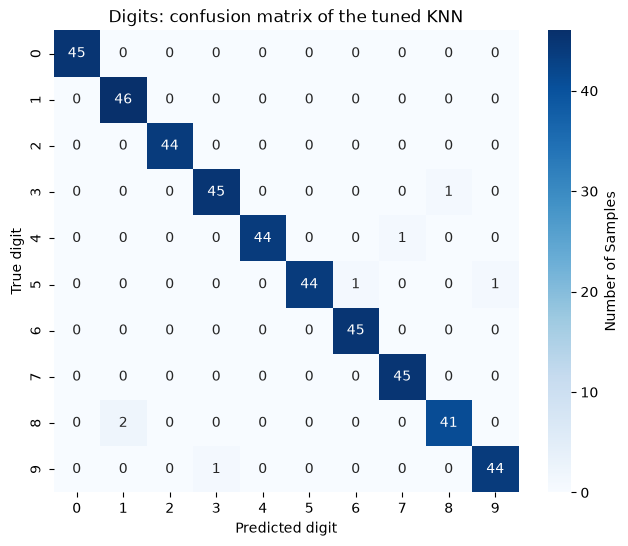

most frequent mistakes (true -> predicted : count):
  8 -> 1 : 2
  3 -> 8 : 1
  4 -> 7 : 1
  5 -> 6 : 1
  5 -> 9 : 1
  9 -> 3 : 1

total mistakes: 7 of 450


In [39]:
y_pred_d = search_digits.predict(Xd_te)
cm_d = confusion_matrix(yd_te, y_pred_d)

plt.figure(figsize=(7.5, 6))
sns.heatmap(cm_d, annot=True, fmt="d", cmap="Blues", cbar_kws={"label": "Number of Samples"})
plt.xlabel("Predicted digit"); plt.ylabel("True digit"); plt.title("Digits: confusion matrix of the tuned KNN"); plt.show()

# the most frequent individual mistakes
off = [(int(t), int(p), int(cm_d[t, p])) for t in range(10) for p in range(10) if t != p and cm_d[t, p] > 0]
print("most frequent mistakes (true -> predicted : count):")
for t, p, c in sorted(off, key=lambda z: -z[2])[:6]:
    print(f"  {t} -> {p} : {c}")
print(f"\ntotal mistakes: {sum(c for _, _, c in off)} of {len(yd_te)}")

In [40]:
rep = pd.DataFrame(classification_report(yd_te, y_pred_d, output_dict=True)).T
rep.round(3)

,precision,recall,f1-score,support
0,1.000,1.000,1.000,45.000
1,0.958,1.000,0.979,46.000
2,1.000,1.000,1.000,44.000
3,0.978,0.978,0.978,46.000
4,1.000,0.978,0.989,45.000
5,1.000,0.957,0.978,46.000
6,0.978,1.000,0.989,45.000
7,0.978,1.000,0.989,45.000
8,0.976,0.953,0.965,43.000
9,0.978,0.978,0.978,45.000


The tuned model makes only **7 mistakes in 450 test images**. The confusion matrix is almost diagonal: the most frequent error is 8 → 1 (twice), and every other mistake occurs once (3 → 8, 4 → 7, 5 → 6, 5 → 9, 9 → 3). The lowest recalls belong to digits 8 (0.953) and 5 (0.957). The lowest precision belongs to digit 1 (0.958), which absorbed the two 8s. With such small counts we should not read a strong pattern into which pairs get confused. The mistakes involve some look-alike shapes, but 7 errors are too few to draw conclusions. The misclassified images below are worth a visual check: at 8×8 pixels some are ambiguous even to a human.

Finally, look at a few of the misclassified images, which is often the fastest way to understand a model's weaknesses:

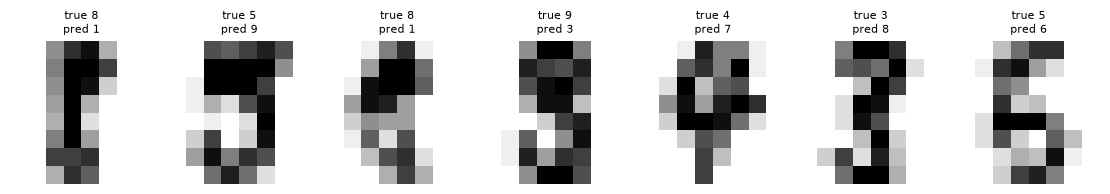

In [41]:
wrong = np.where(y_pred_d != yd_te)[0][:10]
fig, axes = plt.subplots(1, max(len(wrong), 1), figsize=(1.6 * max(len(wrong), 1), 2.2))
for ax, i in zip(np.atleast_1d(axes), wrong):
    ax.imshow(Xd_te[i].reshape(8, 8), cmap="gray_r"); ax.axis("off")
    ax.set_title(f"true {yd_te[i]}\npred {y_pred_d[i]}", fontsize=8)
plt.tight_layout(); plt.show()

## 7. There's more: neighbour-based methods beyond k-NN

The book ends with pointers: experiment with distance metrics in **clustering** and **regression** (we did regression in Section 2.6), and explore methods such as **DBSCAN**, mean shift, spectral clustering, kernel density and the **radius neighbours classifier**, all in scikit-learn.

`RadiusNeighborsClassifier` replaces "the $k$ nearest" by "**all points within a radius $r$**". Dense regions use many neighbours, sparse regions few, and a query with *no* neighbour inside the radius can be flagged as an outlier instead of being forced into a class.

In [42]:
from sklearn.neighbors import RadiusNeighborsClassifier

Xs = StandardScaler().fit_transform(X)                      # (scaling on all data only to keep this demo short)
rn = RadiusNeighborsClassifier(radius=0.8, outlier_label=-1).fit(Xs[::2], y[::2])
pred_rn = rn.predict(Xs[1::2])

is_out = pred_rn == -1
print("test flowers with NO training neighbour within the radius:", int(is_out.sum()), "of", len(pred_rn), "(labelled -1 = outlier)")
print("accuracy on the others:", round(accuracy_score(y[1::2][~is_out], pred_rn[~is_out]), 3))

test flowers with NO training neighbour within the radius: 5 of 75 (labelled -1 = outlier)
accuracy on the others: 0.929


The classifier abstains on the few flowers that live in sparse regions, a behaviour plain $k$-NN cannot offer, since it always finds $k$ neighbours however far away they are.

## Chapter summary

| Concept | Key facts |
|---------|-----------|
| **Distance metric** | Euclidean ($q=2$), Manhattan ($q=1$), Chebyshev ($q\to\infty$) belong to the Minkowski family; cosine, Hamming, Jaccard, correlation serve other data types |
| **KNN** | lazy learner: store data; at prediction take the $k$ nearest points and vote (classification) or average (regression) |
| **$k$** | small $k$ → flexible/noisy (variance); large $k$ → smooth/biased; choose by cross-validation; the extreme $k=n$ ignores the features |
| **`metric` / `p`** | default `minkowski` with `p=2` **is** Euclidean; changing the metric changes who the neighbours are |
| **Scaling** | essential when features differ in units (Wine: 0.70 → 0.96); not helpful when all features already share a scale (Digits) |
| **Irrelevant features** | distance-based models degrade quickly as noise columns are added |
| **Tuning** | `GridSearchCV` (exhaustive) or `RandomizedSearchCV` (sampled); `best_score_` is optimistic, use nested CV or a test set for honest numbers |
| **Evaluation** | CV scores, learning curve, confusion matrix, precision / recall / F1, and ROC-AUC or PR curves for imbalanced data |

### Key takeaways

* **KNN is simple but not trivial**: every decision (metric, $k$, weighting, scaling) changes who the "neighbours" are.
* **Do not trust a single split.** Differences of 1-2 test samples (Iris, circles, checkerboard) were either noise or tiny (Manhattan's edge on the checkerboard averaged 0.6 points); repeated cross-validation told the real story.
* **Always scale** before a distance-based model when features have different units, and put the scaler inside the pipeline.
* **The best grid-search score is biased upward.** Report a test score or a nested-CV score.
* **Accuracy is not enough** for imbalanced data: look at per-class recall and precision, and at ROC-AUC/PR-AUC.

### Self-check questions

<details><summary><b>Q1.</b> Why do <code>metric="euclidean"</code> and <code>metric="minkowski"</code> give identical results in the book's Figure 4.2?</summary>

The default Minkowski exponent is <code>p=2</code>, and Minkowski with <code>p=2</code> is the Euclidean distance. To get a different metric, change <code>p</code> (e.g. <code>p=1</code> for Manhattan).
</details>

<details><summary><b>Q2.</b> What happens to a KNN classifier when <i>k</i> equals the number of training samples?</summary>

Every query has the same neighbours (all training points), so the prediction is always the overall majority class; the features are ignored (under-fitting). With $k=1$ the opposite happens: 100 % training accuracy and an over-fitted, noisy boundary.
</details>

<details><summary><b>Q3.</b> Why must features be scaled before KNN, and when is it unnecessary?</summary>

Distances add up differences across features, so a feature with large numbers dominates (Iris + a 0-1000 noise column dropped to near-chance accuracy). Scaling is unnecessary, and can even slightly hurt, when all features already share the same units and range, as for the Digits pixels.
</details>

<details><summary><b>Q4.</b> Why is <code>grid_search.best_score_</code> an optimistic estimate of future accuracy?</summary>

It is the maximum over many noisy cross-validation scores, so it is biased upward by selection. A separate test set or nested cross-validation gives an honest estimate (Section 4.3).
</details>

<details><summary><b>Q5.</b> A model has 97 % accuracy on a dataset with 95 % majority class. Is it good?</summary>

Not necessarily: "always predict the majority class" already scores 95 %. Look at per-class recall and precision, ROC-AUC or average precision (Section 5.6), where the minority-class recall was only 0.38.
</details>

<details><summary><b>Q6.</b> What do precision and recall measure, and why is F1 a harmonic mean?</summary>

Precision = share of predicted positives that are correct; recall = share of actual positives that are found. The harmonic mean is dominated by the smaller of the two, so F1 is high only when both are high.
</details>

---
**Reference:** Sukup, J. *scikit-learn Cookbook, Third Edition*, Chapter 4, "Building Models with Distance Metrics and Nearest Neighbors". Examples were re-run and extended by the author of this notebook; explanations are paraphrased and supplemented with extra experiments.